CALIDAD DE IMAGEN

[messidor] nivel 0 -> 20051110_38507_0400_PP.png | existe: True


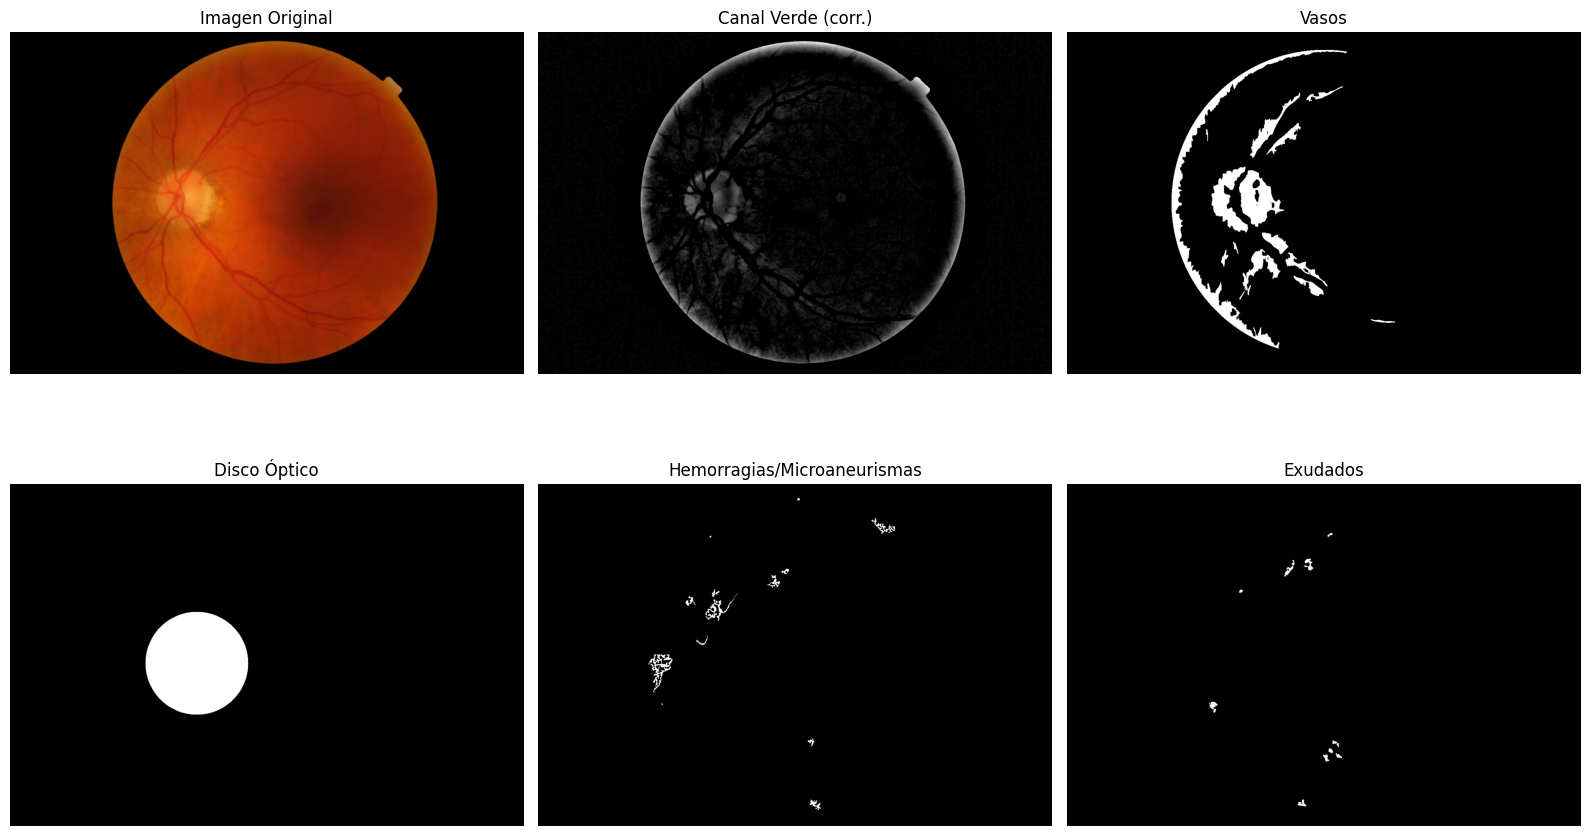

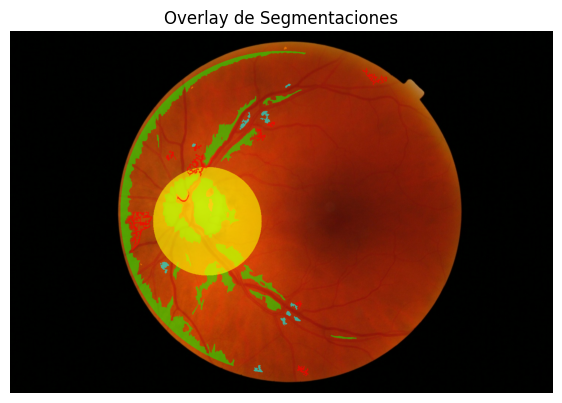

In [1]:
import os, cv2, numpy as np, matplotlib.pyplot as plt, pandas as pd

DATASETS = {
    "messidor": {
        "img_dir": r"C:\Users\drive\OneDrive\Escritorio\data\datos_raw\messidor\train",
        "csv":     r"C:\Users\drive\OneDrive\Escritorio\data\datos_raw\messidor\train.csv",
        "exts":    (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp", ".ppm", ".pgm"),
        "preset": {
            "remove_scars": False,   
            "ring_exclude": True,

            # Vasos
            "vessels_zsigma": 1.08,
            "vessels_min_area": 90,
            "vessels_min_elong": 2.2,
            "vessels_round_cut_area": 850,

            # Lesiones oscuras
            "vessel_excl_dilate": 13,
            "od_excl_dilate": 21,
            "contrast_delta": 14,
            "ma_area": (4, 120),
            "ma_max_ar": 1.8,
            "ma_min_circ": 0.60,
            "hemo_area": (120, 2000),
            "hemo_max_ar": 3.0,

            # Exudados
            "tophat_white": 45,
            "exu_percentile": 99.3,
            "exu_area": (60, 9000),
        }
    },

}

# -------- helpers mínimos --------
import glob

def resolve_filename(img_id: str, base_dir: str,
                     exts=(".png",".jpg",".jpeg",".tif",".tiff",".bmp",".ppm",".pgm")) -> str:
    """
    Devuelve una RUTA RELATIVA a base_dir si encuentra el archivo.
    - Si el CSV trae extensión y existe en raíz -> la usa.
    - Si no, prueba con extensiones en raíz.
    - Si no, busca recursivamente en subcarpetas por nombre (sin extensión), insensible a mayúsculas.
    - Luego intenta coincidencia parcial (por si CSV tiene sufijos).
    """
    # 0) si viene con extensión y existe tal cual en la raíz
    if any(img_id.lower().endswith(e) for e in exts):
        p = os.path.join(base_dir, img_id)
        if os.path.exists(p):
            return img_id  # ya relativo
        # también busca recursivo exacto por nombre de archivo
        patt = os.path.join(base_dir, "**", img_id)
        hits = glob.glob(patt, recursive=True)
        if hits:
            return os.path.relpath(hits[0], base_dir)

    # 1) probar anexando extensiones en la raíz
    base = os.path.splitext(img_id)[0]
    for ext in exts:
        p = os.path.join(base_dir, base + ext)
        if os.path.exists(p):
            return base + ext

    # 2) búsqueda recursiva exacta por basename
    target = base.lower()
    patt = os.path.join(base_dir, "**", "*")
    for p in glob.glob(patt, recursive=True):
        if not os.path.isfile(p):
            continue
        f = os.path.basename(p)
        fbase, fext = os.path.splitext(f)
        if fext.lower() in exts and fbase.lower() == target:
            return os.path.relpath(p, base_dir)

    # 3) coincidencia parcial (por si hay sufijos raros)
    for p in glob.glob(patt, recursive=True):
        if not os.path.isfile(p):
            continue
        f = os.path.basename(p)
        fbase, fext = os.path.splitext(f)
        if fext.lower() in exts and (target in fbase.lower()):
            return os.path.relpath(p, base_dir)

    raise FileNotFoundError(f"No se encontró '{img_id}' en {base_dir} con exts={exts}")
from PIL import Image

def read_image_any(image_path: str):
    """
    Intenta leer con OpenCV; si falla, usa PIL y convierte a BGR.
    Maneja imágenes 16-bit TIFF.
    Devuelve BGR (uint8) para mantener compatibilidad con el resto del pipeline.
    """
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        # fallback con PIL
        pil = Image.open(image_path)
        pil = pil.convert("RGB")  # fuerza 8-bit 3 canales
        rgb = np.array(pil)       # RGB uint8
        bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
        return bgr

    # Si es 16-bit, normaliza a 8-bit
    if img.dtype == np.uint16:
        # escalar a 0..255 de forma robusta (usando percentiles)
        lo = np.percentile(img, 1)
        hi = np.percentile(img, 99)
        img8 = np.clip((img - lo) * (255.0 / max(1, hi - lo)), 0, 255).astype(np.uint8)
        if img8.ndim == 2:
            return cv2.cvtColor(img8, cv2.COLOR_GRAY2BGR)
        return img8

    # Si viene en GRAY 8-bit, pásalo a BGR
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    return img


def comp_metrics_from_bbox(w, h): return max(w, h) / (min(w, h) + 1e-6)

def contour_circularity(mask):
    cnts,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return 0.0
    c = max(cnts, key=cv2.contourArea)
    a = cv2.contourArea(c); p = cv2.arcLength(c, True)
    return 0.0 if p<=0 or a<=0 else float(4*np.pi*a/(p*p))

def gabor_bank_enhance(img_gray, ksize=31, sigma=3.5, lambd=12.0, gamma=0.45, psi=0):
    thetas = np.deg2rad(np.arange(0, 180, 15))
    acc = np.zeros_like(img_gray, dtype=np.float32)
    for th in thetas:
        k = cv2.getGaborKernel((ksize, ksize), sigma, th, lambd, gamma, psi, ktype=cv2.CV_32F)
        acc = np.maximum(acc, cv2.filter2D(img_gray, cv2.CV_32F, k))
    return cv2.normalize(acc, None, 0,255, cv2.NORM_MINMAX).astype(np.uint8)

# -------- pipeline único --------
def run_pipeline(image_path, P):
    img_bgr = read_image_any(image_path)   # <-- en vez de cv2.imread + assert
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H,W = img.shape[:2]
    yy, xx = np.mgrid[0:H,0:W]; cy, cx = H//2, W//2; r = int(min(H,W)*0.48)
    fov_mask = (((yy-cy)**2 + (xx-cx)**2) <= r*r).astype(np.uint8)*255

    ring_mask = np.zeros_like(fov_mask)
    if P.get("ring_exclude", True):
        dist2 = (yy-cy)**2 + (xx-cx)**2
        ring_mask = ((dist2 > (0.93*r)**2) & (dist2 <= r*r)).astype(np.uint8)*255

    g = img[:,:,1]
    g_eq = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(g)
    bg = cv2.GaussianBlur(g_eq, (0,0), sigmaX=25, sigmaY=25)
    g_corr = cv2.normalize(cv2.subtract(g_eq,bg), None, 0,255, cv2.NORM_MINMAX).astype(np.uint8)

    # scars opcional
    if P.get("remove_scars", False):
        g_blur = cv2.GaussianBlur(g_eq, (0,0), 1.5)
        circles = cv2.HoughCircles(g_blur, cv2.HOUGH_GRADIENT, dp=1.2, minDist=18,
                                   param1=80, param2=18, minRadius=6, maxRadius=28)
        scars_mask = np.zeros_like(g, np.uint8)
        if circles is not None:
            circles = np.uint16(np.around(circles[0]))
            for x,y,rad in circles: cv2.circle(scars_mask,(x,y), int(rad*1.1), 255, -1)
        scars_mask = cv2.dilate(scars_mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5)), 1)
    else:
        scars_mask = np.zeros_like(g, np.uint8)

    # --- vasos
    v_big = gabor_bank_enhance(g_corr, ksize=31, sigma=3.5, lambd=12.0, gamma=0.45)
    v_sm  = gabor_bank_enhance(g_corr, ksize=21, sigma=3.2, lambd=9.0,  gamma=0.45)
    vessels_enh = cv2.max(v_big, v_sm)

    v_tmp = vessels_enh.copy()
    v_tmp[(fov_mask==0) | (ring_mask>0) | (scars_mask>0)] = 0
    mu, sd = cv2.meanStdDev(v_tmp, mask=fov_mask)[0][0], cv2.meanStdDev(v_tmp, mask=fov_mask)[1][0]
    hard = (v_tmp > (mu + P["vessels_zsigma"]*sd)).astype(np.uint8)*255
    _, v_otsu = cv2.threshold(v_tmp, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    v_bin = cv2.bitwise_and(hard, v_otsu)
    v_bin = cv2.morphologyEx(v_bin, cv2.MORPH_OPEN,  cv2.getStructuringElement(cv2.MORPH_RECT,(1,3)), 1)
    v_bin = cv2.morphologyEx(v_bin, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT,(1,5)), 1)

    num, lab, stats, _ = cv2.connectedComponentsWithStats(v_bin, 8)
    clean_vessels = np.zeros_like(v_bin)
    for i in range(1,num):
        x,y,w,h,area = stats[i]
        if area < P["vessels_min_area"]: continue
        ar = comp_metrics_from_bbox(w,h)
        if ar < P["vessels_min_elong"] and area < P["vessels_round_cut_area"]: continue
        clean_vessels[lab==i] = 255
    clean_vessels[fov_mask==0] = 0
    clean_vessels = cv2.morphologyEx(clean_vessels, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT,(1,7)), 1)

    # --- disco óptico
    r_ch,g_ch,b_ch = img[:,:,0], img[:,:,1], img[:,:,2]
    comb = cv2.addWeighted(cv2.addWeighted(b_ch,0.4,g_ch,0.4,0),1.0,r_ch,0.2,0)
    comb_blur = cv2.GaussianBlur(comb,(51,51),0)
    final_optic_disc = np.zeros_like(g, np.uint8)
    fov_area = (fov_mask>0).sum()

    best,best_score=None,-1
    for p in [92,94,96,97,98,99]:
        thr = np.percentile(comb_blur, p)
        _, m = cv2.threshold(comb_blur, thr, 255, cv2.THRESH_BINARY)
        kL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(21,21))
        m = cv2.morphologyEx(m, cv2.MORPH_CLOSE,kL)
        m = cv2.morphologyEx(m, cv2.MORPH_OPEN, kL)
        m[(fov_mask==0) | (ring_mask>0)] = 0
        cnts,_ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in cnts:
            a = cv2.contourArea(c)
            if a < 0.003*fov_area or a > 0.05*fov_area: continue
            per = cv2.arcLength(c, True); circ = 4*np.pi*a/(per*per+1e-6)
            if circ < 0.55: continue
            s = a*circ
            if s > best_score: best_score, best = s, c
    if best is not None:
        (cx,cy), rad = cv2.minEnclosingCircle(best)
        rad = int(min(rad*1.1, 0.15*min(H,W))); cx,cy=int(cx),int(cy)
        cv2.circle(final_optic_disc,(cx,cy),rad,255,-1)
    else:
        _,_,_,loc = cv2.minMaxLoc(comb_blur)
        cv2.circle(final_optic_disc, loc, int(0.06*min(H,W)), 255, -1)

    # exclusiones
    vessel_excl = cv2.dilate(clean_vessels, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(P["vessel_excl_dilate"],)*2),1)
    excl       = cv2.dilate(final_optic_disc, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(P["od_excl_dilate"],)*2),1)

    # --- oscuras
    bh_s = cv2.morphologyEx(g_corr, cv2.MORPH_BLACKHAT, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(7,7)))
    bh_m = cv2.morphologyEx(g_corr, cv2.MORPH_BLACKHAT, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(15,15)))
    bh   = cv2.max(bh_s, bh_m)
    bh[(fov_mask==0)|(ring_mask>0)|(vessel_excl==255)|(excl==255)|(scars_mask>0)] = 0

    dog = cv2.GaussianBlur(g_corr,(0,0),1.0) - cv2.GaussianBlur(g_corr,(0,0),2.0)
    dog = cv2.normalize(dog,None,0,255,cv2.NORM_MINMAX).astype(np.uint8); dog[fov_mask==0]=0
    cand = cv2.addWeighted(bh,0.7,dog,0.3,0)
    _, dark_bin = cv2.threshold(cand, 0,255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    dark_bin = cv2.medianBlur(dark_bin,3)
    dark_bin = cv2.morphologyEx(dark_bin, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3)), 1)
    near_vess = cv2.dilate(clean_vessels, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(9,9)), 1)
    dark_bin[near_vess==255] = 0

    num, lab, stats, cents = cv2.connectedComponentsWithStats(dark_bin, 8)
    micro_mask = np.zeros_like(dark_bin); hemo_mask = np.zeros_like(dark_bin)
    for i in range(1,num):
        x,y,w,h,area = stats[i]
        if not (4 <= area <= 2500): continue
        cx,cy = int(cents[i][0]), int(cents[i][1])
        y1,y2=max(0,cy-10),min(H,cy+10); x1,x2=max(0,cx-10),min(W,cx+10)
        roi = g_corr[y1:y2,x1:x2]; mroi = (lab[y1:y2,x1:x2]==i)
        if mroi.sum()==0: continue
        lesion = roi[mroi].mean(); back = roi[~mroi].mean() if (~mroi).sum()>0 else lesion+1
        if lesion >= back - P["contrast_delta"]: continue
        ar = comp_metrics_from_bbox(w,h)
        cmask = (lab==i).astype(np.uint8)*255; circ = contour_circularity(cmask)
        if P["ma_area"][0] <= area <= P["ma_area"][1] and ar <= P["ma_max_ar"] and circ >= P["ma_min_circ"]:
            micro_mask[lab==i]=255
        elif P["hemo_area"][0] < area <= P["hemo_area"][1] and ar <= P["hemo_max_ar"]:
            hemo_mask[lab==i]=255

    # --- exudados
    wh = cv2.morphologyEx(g_corr, cv2.MORPH_TOPHAT,
                          cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(P["tophat_white"],)*2))
    wh[(fov_mask==0)|(ring_mask>0)|(vessel_excl==255)|(excl==255)|(scars_mask>0)] = 0
    vals = wh[fov_mask>0]; p = np.percentile(vals, P["exu_percentile"])
    _, exu_otsu = cv2.threshold(wh, 0,255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    exudates = cv2.bitwise_and(exu_otsu, (wh>=p).astype(np.uint8)*255)
    exudates = cv2.medianBlur(exudates,3)
    exudates = cv2.morphologyEx(exudates, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3)), 1)

    num, lab, stats, _ = cv2.connectedComponentsWithStats(exudates, 8)
    exu_clean = np.zeros_like(exudates)
    for i in range(1,num):
        A = stats[i, cv2.CC_STAT_AREA]
        if P["exu_area"][0] <= A <= P["exu_area"][1]:
            cmask = (lab==i).astype(np.uint8)*255; circ = contour_circularity(cmask)
            if P.get("remove_scars", False) and circ > 0.82 and A < 1200:  # filtra scars redonditos
                continue
            exu_clean[lab==i]=255
    exudates = exu_clean

    # ----- visualización (opcional) -----
    plt.figure(figsize=(16,10))
    plt.subplot(2,3,1); plt.imshow(img);                 plt.title("Imagen Original"); plt.axis('off')
    plt.subplot(2,3,2); plt.imshow(g_corr, cmap='gray'); plt.title("Canal Verde (corr.)"); plt.axis('off')
    plt.subplot(2,3,3); plt.imshow(clean_vessels, cmap='gray'); plt.title("Vasos"); plt.axis('off')
    plt.subplot(2,3,4); plt.imshow(final_optic_disc, cmap='gray'); plt.title("Disco Óptico"); plt.axis('off')
    plt.subplot(2,3,5); plt.imshow(cv2.bitwise_or(micro_mask, hemo_mask), cmap='gray'); plt.title("Hemorragias/Microaneurismas"); plt.axis('off')
    plt.subplot(2,3,6); plt.imshow(exudates, cmap='gray'); plt.title("Exudados"); plt.axis('off')
    plt.tight_layout(); plt.show()

    overlay = img.copy()
    def paint(mask, color, alpha=0.6):
        c = np.zeros_like(img); c[:] = color
        m3 = np.dstack([mask]*3)
        return np.where(m3>0, (alpha*c + (1-alpha)*overlay).astype(np.uint8), overlay)
    overlay = paint(clean_vessels,(0,255,0),0.5)
    overlay = paint(final_optic_disc,(255,255,0),0.6)
    overlay = paint(hemo_mask,(255,0,0),0.7)
    overlay = paint(micro_mask,(255,128,0),0.7)
    overlay = paint(exudates,(0,255,255),0.6)

    plt.figure(figsize=(7,7)); plt.imshow(overlay); plt.title("Overlay de Segmentaciones"); plt.axis('off'); plt.show()

    fov_pixels = max(1, int(fov_mask.sum()/255))
    metrics = {
        "vessel_px": int((clean_vessels>0).sum()),
        "vessel_%FOV": round(100*(clean_vessels>0).sum()/fov_pixels, 2),
        "MA_px": int((micro_mask>0).sum()),
        "Hemo_px": int((hemo_mask>0).sum()),
        "Exud_px": int((exudates>0).sum()),
    }
    return {"overlay": overlay, "metrics": metrics}

# -------- selector genérico: mismo código para ambos datasets --------
# ... (todo tu código igual arriba: DATASETS, resolve_filename, read_image_any, gabor_bank_enhance, run_pipeline)

def pick_and_run(dataset="messidor", level=0, seed=42, force_image_id=None):
    cfg = DATASETS[dataset]

    # leer CSV con columnas image y level
    df = pd.read_csv(cfg["csv"])
    # asegurar tipos
    if 'level' in df.columns:
        df['level'] = pd.to_numeric(df['level'], errors='coerce')

    assert {'image','level'}.issubset(df.columns), f"Faltan columnas en {cfg['csv']}"

    df_lvl = df[df['level'] == level].copy()
    assert not df_lvl.empty, f"No hay imágenes con nivel {level} en {dataset}."

    if force_image_id:
        # aceptar con o sin extensión
        base = os.path.splitext(str(force_image_id))[0]
        row = df_lvl[df_lvl['image'].astype(str).str.replace(r'\.(png|jpe?g|tif?f|bmp|ppm|pgm)$','', regex=True, case=False) == base]
        if row.empty:
            raise ValueError(f"{force_image_id} no está en el CSV con nivel {level}.")
        img_id = str(row.iloc[0]['image'])
    else:
        img_id = str(df_lvl.sample(1, random_state=seed).iloc[0]['image'])

    # resolver ruta real (busca recursivo si hace falta)
    image_name = resolve_filename(img_id, cfg["img_dir"], exts=cfg["exts"])
    image_path = os.path.join(cfg["img_dir"], image_name)
    print(f"[{dataset}] nivel {level} -> {image_name} | existe: {os.path.exists(image_path)}")

    return run_pipeline(image_path, cfg["preset"])

# --- EJECUCIÓN ---
res = pick_and_run(dataset="messidor", level=0, seed=42)

[messidor] nivel 4 -> 20051020_45110_0100_PP.png | existe: True


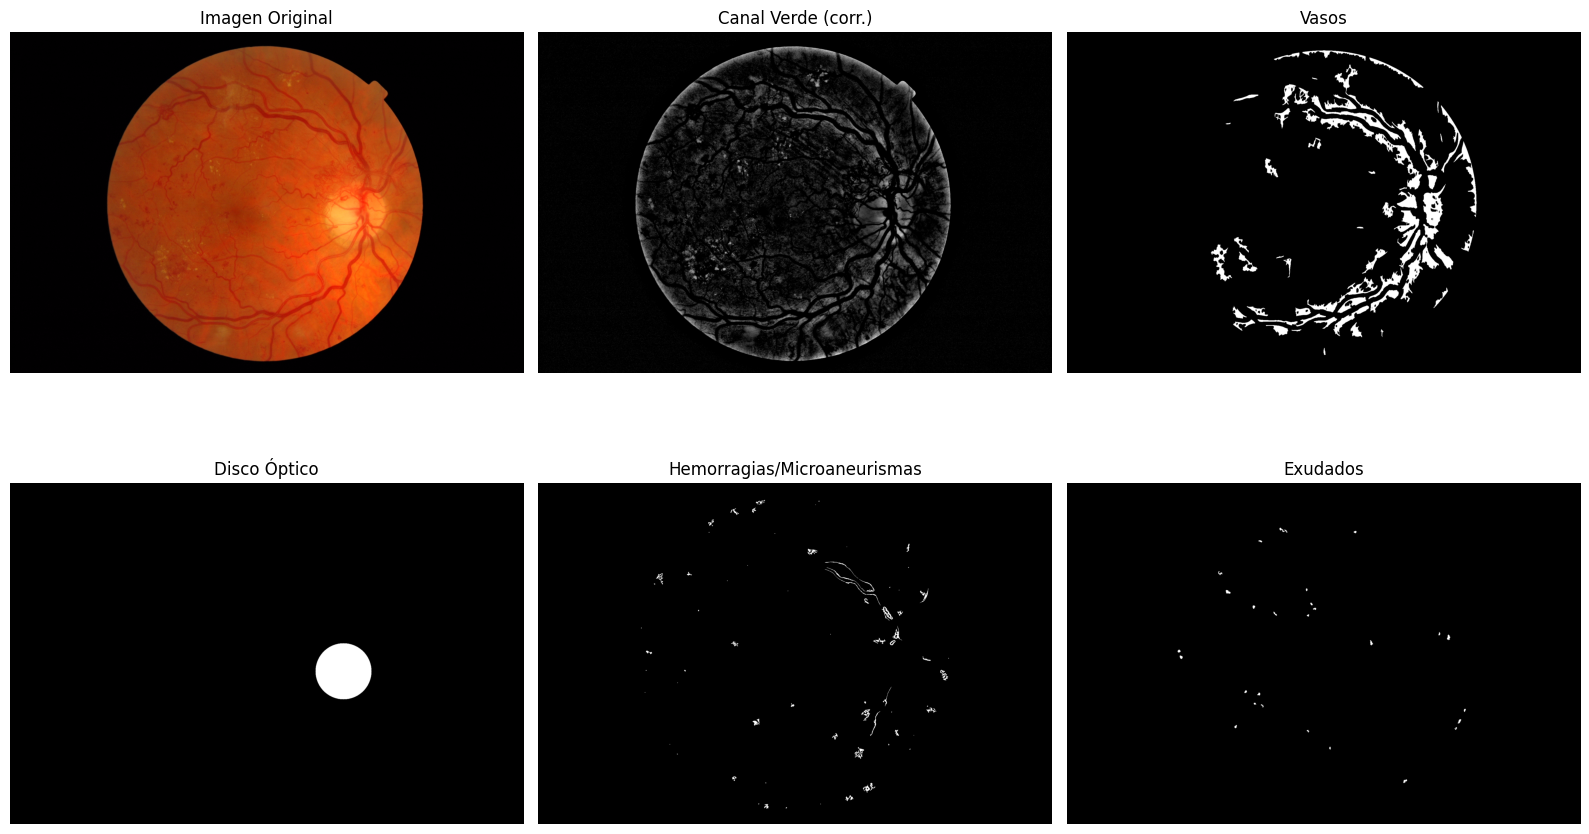

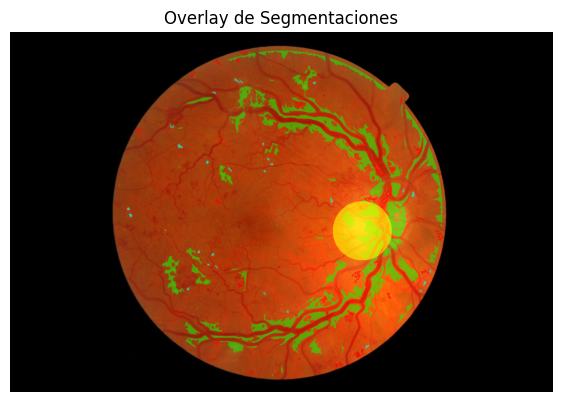

In [6]:
import os, cv2, numpy as np, matplotlib.pyplot as plt, pandas as pd

DATASETS = {
    "messidor": {
        "img_dir": r"C:\Users\drive\OneDrive\Escritorio\data\datos_raw\messidor\train",
        "csv":     r"C:\Users\drive\OneDrive\Escritorio\data\datos_raw\messidor\train.csv",
        "exts":    (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp", ".ppm", ".pgm"),
        "preset": {
            "remove_scars": False,   
            "ring_exclude": True,

            # Vasos
            "vessels_zsigma": 1.08,
            "vessels_min_area": 90,
            "vessels_min_elong": 2.2,
            "vessels_round_cut_area": 850,

            # Lesiones oscuras
            "vessel_excl_dilate": 13,
            "od_excl_dilate": 21,
            "contrast_delta": 14,
            "ma_area": (4, 120),
            "ma_max_ar": 1.8,
            "ma_min_circ": 0.60,
            "hemo_area": (120, 2000),
            "hemo_max_ar": 3.0,

            # Exudados
            "tophat_white": 45,
            "exu_percentile": 99.3,
            "exu_area": (60, 9000),
        }
    },

}

# -------- helpers mínimos --------
import glob

def resolve_filename(img_id: str, base_dir: str,
                     exts=(".png",".jpg",".jpeg",".tif",".tiff",".bmp",".ppm",".pgm")) -> str:
    """
    Devuelve una RUTA RELATIVA a base_dir si encuentra el archivo.
    - Si el CSV trae extensión y existe en raíz -> la usa.
    - Si no, prueba con extensiones en raíz.
    - Si no, busca recursivamente en subcarpetas por nombre (sin extensión), insensible a mayúsculas.
    - Luego intenta coincidencia parcial (por si CSV tiene sufijos).
    """
    # 0) si viene con extensión y existe tal cual en la raíz
    if any(img_id.lower().endswith(e) for e in exts):
        p = os.path.join(base_dir, img_id)
        if os.path.exists(p):
            return img_id  # ya relativo
        # también busca recursivo exacto por nombre de archivo
        patt = os.path.join(base_dir, "**", img_id)
        hits = glob.glob(patt, recursive=True)
        if hits:
            return os.path.relpath(hits[0], base_dir)

    # 1) probar anexando extensiones en la raíz
    base = os.path.splitext(img_id)[0]
    for ext in exts:
        p = os.path.join(base_dir, base + ext)
        if os.path.exists(p):
            return base + ext

    # 2) búsqueda recursiva exacta por basename
    target = base.lower()
    patt = os.path.join(base_dir, "**", "*")
    for p in glob.glob(patt, recursive=True):
        if not os.path.isfile(p):
            continue
        f = os.path.basename(p)
        fbase, fext = os.path.splitext(f)
        if fext.lower() in exts and fbase.lower() == target:
            return os.path.relpath(p, base_dir)

    # 3) coincidencia parcial (por si hay sufijos raros)
    for p in glob.glob(patt, recursive=True):
        if not os.path.isfile(p):
            continue
        f = os.path.basename(p)
        fbase, fext = os.path.splitext(f)
        if fext.lower() in exts and (target in fbase.lower()):
            return os.path.relpath(p, base_dir)

    raise FileNotFoundError(f"No se encontró '{img_id}' en {base_dir} con exts={exts}")
from PIL import Image

def read_image_any(image_path: str):
    """
    Intenta leer con OpenCV; si falla, usa PIL y convierte a BGR.
    Maneja imágenes 16-bit TIFF.
    Devuelve BGR (uint8) para mantener compatibilidad con el resto del pipeline.
    """
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img is None:
        # fallback con PIL
        pil = Image.open(image_path)
        pil = pil.convert("RGB")  # fuerza 8-bit 3 canales
        rgb = np.array(pil)       # RGB uint8
        bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
        return bgr

    # Si es 16-bit, normaliza a 8-bit
    if img.dtype == np.uint16:
        # escalar a 0..255 de forma robusta (usando percentiles)
        lo = np.percentile(img, 1)
        hi = np.percentile(img, 99)
        img8 = np.clip((img - lo) * (255.0 / max(1, hi - lo)), 0, 255).astype(np.uint8)
        if img8.ndim == 2:
            return cv2.cvtColor(img8, cv2.COLOR_GRAY2BGR)
        return img8

    # Si viene en GRAY 8-bit, pásalo a BGR
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    return img


def comp_metrics_from_bbox(w, h): return max(w, h) / (min(w, h) + 1e-6)

def contour_circularity(mask):
    cnts,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts: return 0.0
    c = max(cnts, key=cv2.contourArea)
    a = cv2.contourArea(c); p = cv2.arcLength(c, True)
    return 0.0 if p<=0 or a<=0 else float(4*np.pi*a/(p*p))

def gabor_bank_enhance(img_gray, ksize=31, sigma=3.5, lambd=12.0, gamma=0.45, psi=0):
    thetas = np.deg2rad(np.arange(0, 180, 15))
    acc = np.zeros_like(img_gray, dtype=np.float32)
    for th in thetas:
        k = cv2.getGaborKernel((ksize, ksize), sigma, th, lambd, gamma, psi, ktype=cv2.CV_32F)
        acc = np.maximum(acc, cv2.filter2D(img_gray, cv2.CV_32F, k))
    return cv2.normalize(acc, None, 0,255, cv2.NORM_MINMAX).astype(np.uint8)

# -------- pipeline único --------
def run_pipeline(image_path, P):
    img_bgr = read_image_any(image_path)   # <-- en vez de cv2.imread + assert
    img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    H,W = img.shape[:2]
    yy, xx = np.mgrid[0:H,0:W]; cy, cx = H//2, W//2; r = int(min(H,W)*0.48)
    fov_mask = (((yy-cy)**2 + (xx-cx)**2) <= r*r).astype(np.uint8)*255

    ring_mask = np.zeros_like(fov_mask)
    if P.get("ring_exclude", True):
        dist2 = (yy-cy)**2 + (xx-cx)**2
        ring_mask = ((dist2 > (0.93*r)**2) & (dist2 <= r*r)).astype(np.uint8)*255

    g = img[:,:,1]
    g_eq = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8)).apply(g)
    bg = cv2.GaussianBlur(g_eq, (0,0), sigmaX=25, sigmaY=25)
    g_corr = cv2.normalize(cv2.subtract(g_eq,bg), None, 0,255, cv2.NORM_MINMAX).astype(np.uint8)

    # scars opcional
    if P.get("remove_scars", False):
        g_blur = cv2.GaussianBlur(g_eq, (0,0), 1.5)
        circles = cv2.HoughCircles(g_blur, cv2.HOUGH_GRADIENT, dp=1.2, minDist=18,
                                   param1=80, param2=18, minRadius=6, maxRadius=28)
        scars_mask = np.zeros_like(g, np.uint8)
        if circles is not None:
            circles = np.uint16(np.around(circles[0]))
            for x,y,rad in circles: cv2.circle(scars_mask,(x,y), int(rad*1.1), 255, -1)
        scars_mask = cv2.dilate(scars_mask, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5)), 1)
    else:
        scars_mask = np.zeros_like(g, np.uint8)

    # --- vasos
    v_big = gabor_bank_enhance(g_corr, ksize=31, sigma=3.5, lambd=12.0, gamma=0.45)
    v_sm  = gabor_bank_enhance(g_corr, ksize=21, sigma=3.2, lambd=9.0,  gamma=0.45)
    vessels_enh = cv2.max(v_big, v_sm)

    v_tmp = vessels_enh.copy()
    v_tmp[(fov_mask==0) | (ring_mask>0) | (scars_mask>0)] = 0
    mu, sd = cv2.meanStdDev(v_tmp, mask=fov_mask)[0][0], cv2.meanStdDev(v_tmp, mask=fov_mask)[1][0]
    hard = (v_tmp > (mu + P["vessels_zsigma"]*sd)).astype(np.uint8)*255
    _, v_otsu = cv2.threshold(v_tmp, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    v_bin = cv2.bitwise_and(hard, v_otsu)
    v_bin = cv2.morphologyEx(v_bin, cv2.MORPH_OPEN,  cv2.getStructuringElement(cv2.MORPH_RECT,(1,3)), 1)
    v_bin = cv2.morphologyEx(v_bin, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT,(1,5)), 1)

    num, lab, stats, _ = cv2.connectedComponentsWithStats(v_bin, 8)
    clean_vessels = np.zeros_like(v_bin)
    for i in range(1,num):
        x,y,w,h,area = stats[i]
        if area < P["vessels_min_area"]: continue
        ar = comp_metrics_from_bbox(w,h)
        if ar < P["vessels_min_elong"] and area < P["vessels_round_cut_area"]: continue
        clean_vessels[lab==i] = 255
    clean_vessels[fov_mask==0] = 0
    clean_vessels = cv2.morphologyEx(clean_vessels, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT,(1,7)), 1)

    # --- disco óptico
    r_ch,g_ch,b_ch = img[:,:,0], img[:,:,1], img[:,:,2]
    comb = cv2.addWeighted(cv2.addWeighted(b_ch,0.4,g_ch,0.4,0),1.0,r_ch,0.2,0)
    comb_blur = cv2.GaussianBlur(comb,(51,51),0)
    final_optic_disc = np.zeros_like(g, np.uint8)
    fov_area = (fov_mask>0).sum()

    best,best_score=None,-1
    for p in [92,94,96,97,98,99]:
        thr = np.percentile(comb_blur, p)
        _, m = cv2.threshold(comb_blur, thr, 255, cv2.THRESH_BINARY)
        kL = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(21,21))
        m = cv2.morphologyEx(m, cv2.MORPH_CLOSE,kL)
        m = cv2.morphologyEx(m, cv2.MORPH_OPEN, kL)
        m[(fov_mask==0) | (ring_mask>0)] = 0
        cnts,_ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in cnts:
            a = cv2.contourArea(c)
            if a < 0.003*fov_area or a > 0.05*fov_area: continue
            per = cv2.arcLength(c, True); circ = 4*np.pi*a/(per*per+1e-6)
            if circ < 0.55: continue
            s = a*circ
            if s > best_score: best_score, best = s, c
    if best is not None:
        (cx,cy), rad = cv2.minEnclosingCircle(best)
        rad = int(min(rad*1.1, 0.15*min(H,W))); cx,cy=int(cx),int(cy)
        cv2.circle(final_optic_disc,(cx,cy),rad,255,-1)
    else:
        _,_,_,loc = cv2.minMaxLoc(comb_blur)
        cv2.circle(final_optic_disc, loc, int(0.06*min(H,W)), 255, -1)

    # exclusiones
    vessel_excl = cv2.dilate(clean_vessels, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(P["vessel_excl_dilate"],)*2),1)
    excl       = cv2.dilate(final_optic_disc, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(P["od_excl_dilate"],)*2),1)

    # --- oscuras
    bh_s = cv2.morphologyEx(g_corr, cv2.MORPH_BLACKHAT, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(7,7)))
    bh_m = cv2.morphologyEx(g_corr, cv2.MORPH_BLACKHAT, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(15,15)))
    bh   = cv2.max(bh_s, bh_m)
    bh[(fov_mask==0)|(ring_mask>0)|(vessel_excl==255)|(excl==255)|(scars_mask>0)] = 0

    dog = cv2.GaussianBlur(g_corr,(0,0),1.0) - cv2.GaussianBlur(g_corr,(0,0),2.0)
    dog = cv2.normalize(dog,None,0,255,cv2.NORM_MINMAX).astype(np.uint8); dog[fov_mask==0]=0
    cand = cv2.addWeighted(bh,0.7,dog,0.3,0)
    _, dark_bin = cv2.threshold(cand, 0,255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    dark_bin = cv2.medianBlur(dark_bin,3)
    dark_bin = cv2.morphologyEx(dark_bin, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3)), 1)
    near_vess = cv2.dilate(clean_vessels, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(9,9)), 1)
    dark_bin[near_vess==255] = 0

    num, lab, stats, cents = cv2.connectedComponentsWithStats(dark_bin, 8)
    micro_mask = np.zeros_like(dark_bin); hemo_mask = np.zeros_like(dark_bin)
    for i in range(1,num):
        x,y,w,h,area = stats[i]
        if not (4 <= area <= 2500): continue
        cx,cy = int(cents[i][0]), int(cents[i][1])
        y1,y2=max(0,cy-10),min(H,cy+10); x1,x2=max(0,cx-10),min(W,cx+10)
        roi = g_corr[y1:y2,x1:x2]; mroi = (lab[y1:y2,x1:x2]==i)
        if mroi.sum()==0: continue
        lesion = roi[mroi].mean(); back = roi[~mroi].mean() if (~mroi).sum()>0 else lesion+1
        if lesion >= back - P["contrast_delta"]: continue
        ar = comp_metrics_from_bbox(w,h)
        cmask = (lab==i).astype(np.uint8)*255; circ = contour_circularity(cmask)
        if P["ma_area"][0] <= area <= P["ma_area"][1] and ar <= P["ma_max_ar"] and circ >= P["ma_min_circ"]:
            micro_mask[lab==i]=255
        elif P["hemo_area"][0] < area <= P["hemo_area"][1] and ar <= P["hemo_max_ar"]:
            hemo_mask[lab==i]=255

    # --- exudados
    wh = cv2.morphologyEx(g_corr, cv2.MORPH_TOPHAT,
                          cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(P["tophat_white"],)*2))
    wh[(fov_mask==0)|(ring_mask>0)|(vessel_excl==255)|(excl==255)|(scars_mask>0)] = 0
    vals = wh[fov_mask>0]; p = np.percentile(vals, P["exu_percentile"])
    _, exu_otsu = cv2.threshold(wh, 0,255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    exudates = cv2.bitwise_and(exu_otsu, (wh>=p).astype(np.uint8)*255)
    exudates = cv2.medianBlur(exudates,3)
    exudates = cv2.morphologyEx(exudates, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3)), 1)

    num, lab, stats, _ = cv2.connectedComponentsWithStats(exudates, 8)
    exu_clean = np.zeros_like(exudates)
    for i in range(1,num):
        A = stats[i, cv2.CC_STAT_AREA]
        if P["exu_area"][0] <= A <= P["exu_area"][1]:
            cmask = (lab==i).astype(np.uint8)*255; circ = contour_circularity(cmask)
            if P.get("remove_scars", False) and circ > 0.82 and A < 1200:  # filtra scars redonditos
                continue
            exu_clean[lab==i]=255
    exudates = exu_clean

    # ----- visualización (opcional) -----
    plt.figure(figsize=(16,10))
    plt.subplot(2,3,1); plt.imshow(img);                 plt.title("Imagen Original"); plt.axis('off')
    plt.subplot(2,3,2); plt.imshow(g_corr, cmap='gray'); plt.title("Canal Verde (corr.)"); plt.axis('off')
    plt.subplot(2,3,3); plt.imshow(clean_vessels, cmap='gray'); plt.title("Vasos"); plt.axis('off')
    plt.subplot(2,3,4); plt.imshow(final_optic_disc, cmap='gray'); plt.title("Disco Óptico"); plt.axis('off')
    plt.subplot(2,3,5); plt.imshow(cv2.bitwise_or(micro_mask, hemo_mask), cmap='gray'); plt.title("Hemorragias/Microaneurismas"); plt.axis('off')
    plt.subplot(2,3,6); plt.imshow(exudates, cmap='gray'); plt.title("Exudados"); plt.axis('off')
    plt.tight_layout(); plt.show()

    overlay = img.copy()
    def paint(mask, color, alpha=0.6):
        c = np.zeros_like(img); c[:] = color
        m3 = np.dstack([mask]*3)
        return np.where(m3>0, (alpha*c + (1-alpha)*overlay).astype(np.uint8), overlay)
    overlay = paint(clean_vessels,(0,255,0),0.5)
    overlay = paint(final_optic_disc,(255,255,0),0.6)
    overlay = paint(hemo_mask,(255,0,0),0.7)
    overlay = paint(micro_mask,(255,128,0),0.7)
    overlay = paint(exudates,(0,255,255),0.6)

    plt.figure(figsize=(7,7)); plt.imshow(overlay); plt.title("Overlay de Segmentaciones"); plt.axis('off'); plt.show()

    fov_pixels = max(1, int(fov_mask.sum()/255))
    metrics = {
        "vessel_px": int((clean_vessels>0).sum()),
        "vessel_%FOV": round(100*(clean_vessels>0).sum()/fov_pixels, 2),
        "MA_px": int((micro_mask>0).sum()),
        "Hemo_px": int((hemo_mask>0).sum()),
        "Exud_px": int((exudates>0).sum()),
    }
    return {"overlay": overlay, "metrics": metrics}

# -------- selector genérico: mismo código para ambos datasets --------
# ... (todo tu código igual arriba: DATASETS, resolve_filename, read_image_any, gabor_bank_enhance, run_pipeline)

def pick_and_run(dataset="messidor", level=4, seed=42, force_image_id=None):
    cfg = DATASETS[dataset]

    # leer CSV con columnas image y level
    df = pd.read_csv(cfg["csv"])
    # asegurar tipos
    if 'level' in df.columns:
        df['level'] = pd.to_numeric(df['level'], errors='coerce')

    assert {'image','level'}.issubset(df.columns), f"Faltan columnas en {cfg['csv']}"

    df_lvl = df[df['level'] == level].copy()
    assert not df_lvl.empty, f"No hay imágenes con nivel {level} en {dataset}."

    if force_image_id:
        # aceptar con o sin extensión
        base = os.path.splitext(str(force_image_id))[0]
        row = df_lvl[df_lvl['image'].astype(str).str.replace(r'\.(png|jpe?g|tif?f|bmp|ppm|pgm)$','', regex=True, case=False) == base]
        if row.empty:
            raise ValueError(f"{force_image_id} no está en el CSV con nivel {level}.")
        img_id = str(row.iloc[0]['image'])
    else:
        img_id = str(df_lvl.sample(1, random_state=seed).iloc[0]['image'])

    # resolver ruta real (busca recursivo si hace falta)
    image_name = resolve_filename(img_id, cfg["img_dir"], exts=cfg["exts"])
    image_path = os.path.join(cfg["img_dir"], image_name)
    print(f"[{dataset}] nivel {level} -> {image_name} | existe: {os.path.exists(image_path)}")

    return run_pipeline(image_path, cfg["preset"])

# --- EJECUCIÓN ---
res = pick_and_run(dataset="messidor", level=4, seed=42)